# Day 27 of ML 30-Days Challenge

# Task

**Ensemble Methods (Bagging, Boosting, Random Forest, AdaBoost, XGBoost)**: Deep dive into ensemble techniques. Understand the difference between Bagging (like Random Forest) and Boosting (like AdaBoost, XGBoost) and when to use each for higher accuracy.

- **Bagging:**
  - Train many copies of the same model on different random slices of the data, then vote.
  - Helps smooth out “noisy” decisions and reduces overfitting.
- **AdaBoost:**
  - Build tiny trees one after another.
  - Each new tree pays extra attention to the mistakes of the previous ones.
  - Turns many weak rules into a stronger model, but can chase noisy labels.
- **Gradient Boosting (XGBoost):**
  - Also builds trees one by one, but each new tree tries to fix the remaining errors using a careful, step‑by‑step approach.
  - Adds regularization and smart sampling to control overfitting and boost accuracy.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

###1. Create a 500-row non-linear dataset

In [35]:
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y )

X.shape, y.shape

((500, 2), (500,))

###2. Define models (you know, doing all at once)

In [36]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=None, random_state=42),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        max_samples=0.8,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=200,
        learning_rate=0.5,
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        use_label_encoder=False
    ),
}

###3. Train, predict, evaluate

In [37]:
metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics.append({"Model": name, "Accuracy": acc, "F1": f1})

results_df = pd.DataFrame(metrics).sort_values(by="Accuracy", ascending=False)
print("\nEvaluation metrics:\n")
print(results_df.to_string(index=False))


Evaluation metrics:

        Model  Accuracy       F1
Decision Tree  0.946667 0.947368
      Bagging  0.946667 0.945946
      XGBoost  0.920000 0.918919
     AdaBoost  0.906667 0.905405


###4. Build a single figure visualizing all models

In [38]:
def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    scatter = ax.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolor="k", s=20)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

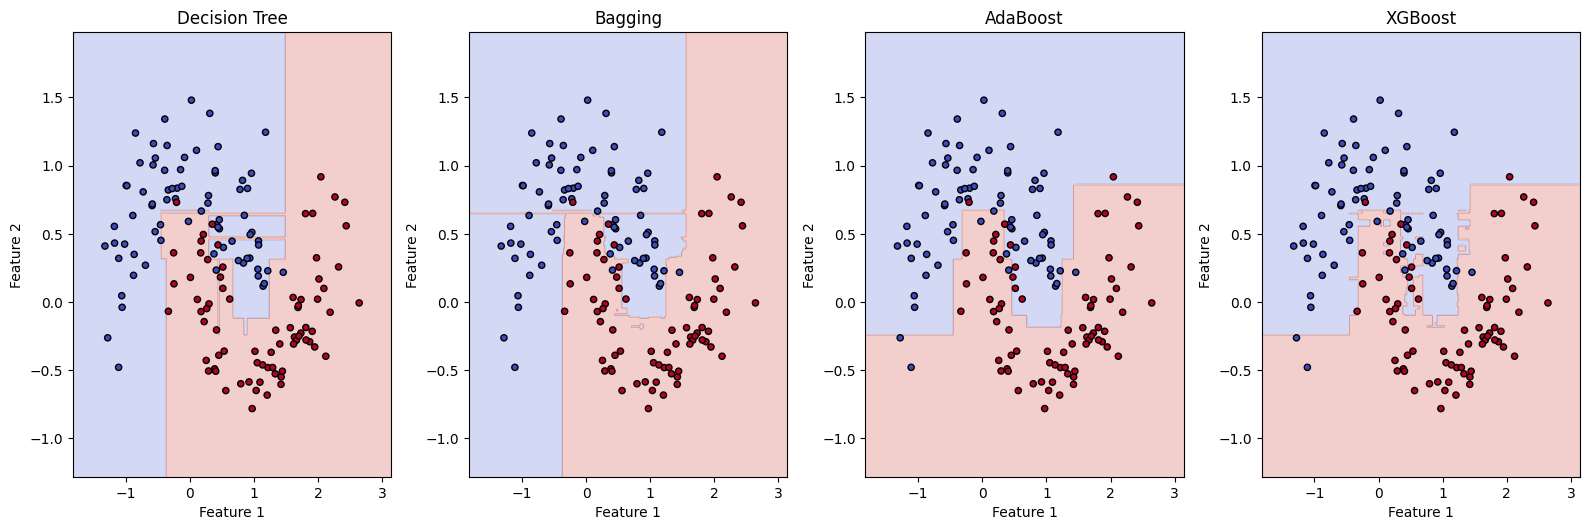

In [39]:
model_names = list(models.keys())
n_models = len(model_names)

fig = plt.figure(figsize=(4*n_models, 10))

for i, name in enumerate(model_names, start=1):
    ax = plt.subplot(2, n_models, i)
    plot_decision_boundary(ax, models[name], X_test, y_test, name)


plt.tight_layout()
plt.show()